<a href="https://colab.research.google.com/github/asakicode/git-study-AIM-/blob/main/BDAI_%EC%A0%84%EC%B2%98%EB%A6%AC_5%EC%A3%BC%EC%B0%A8_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MCAR (Missing Completely at Random):** 결측이 완전히 무작위로 발생하며, 다른 변수들과 독립적 데이터를 삭제하거나 단순 대체해도 편향이 발생하지 않는다.

**MAR (Missing at Random):** 결측이 관측된 다른 변수(X)에 의존하여 발생한다. 이를 무시하면 추정치에 편향이 생기므로 모델 기반 대체가 필요하다.

**MNAR (Missing Not at Random):** 결측이 측정되지 않은 요인이나 자기 자신(Y)에 의존한다. 완전한 교정이 어렵고 심각한 편향을 초래할 수 있다.

**Simple Imputer(단순대체법)**
전략: 각 특성의 관측값들을 이용해 "평균(mean)", "중앙값(median)", "최빈값(most frequent)", 또는 "상수(constant)"로 결측치를 채운다.


장단점: 구현이 매우 빠르고 단순하여 베이스라인 모델을 만들 때 유용하지만, 데이터의 분산을 축소시키고 결측치의 불확실성을 반영하지 못한다는 단점이 있다.



**Interpolation(보간법)**

특징: 주로 시계열(Time Series) 데이터에서 전후 관계를 고려해 값을 채울 때 사용된다.

주요 방식:선형 보간(Linear Interpolation): 인접한 두 점을 직선으로 연결하여 그 사이의 값을 계산한다.

2차 보간(Quadratic Interpolation): 곡선 형태의 흐름을 반영하여 더 복잡한 패턴을 추정한다.Forward Fill / Back Fill: 이전 값으로 채우거나 다음 값으로 채우는 방식이다.




**MICE (반복 다변량 결측 대체)**
Multiple Imputation by Chained Equations의 약자로, 여러 변수 간의 관계를 고려하여 결측치를 반복적으로 채우는 고급 기법. scikit-learn에서는 IterativeImputer로 구현되어있다.

작동 원리:각 변수의 결측치를 평균 등으로 임시 초기화한다.특정 변수 X_1의 결측치를 다른 변수들을 이용해 예측하여 채운다.이 과정을 모든 변수에 대해 순환하며 여러 번 반복하여 값이 수렴할 때까지 진행합니다.

장점: 변수 간의 상관관계를 유지할 수 있으며, 특히 확률적 오차를 추가하는 설정을 통해 데이터의 불확실성을 현실적으로 모사할 수 있다.

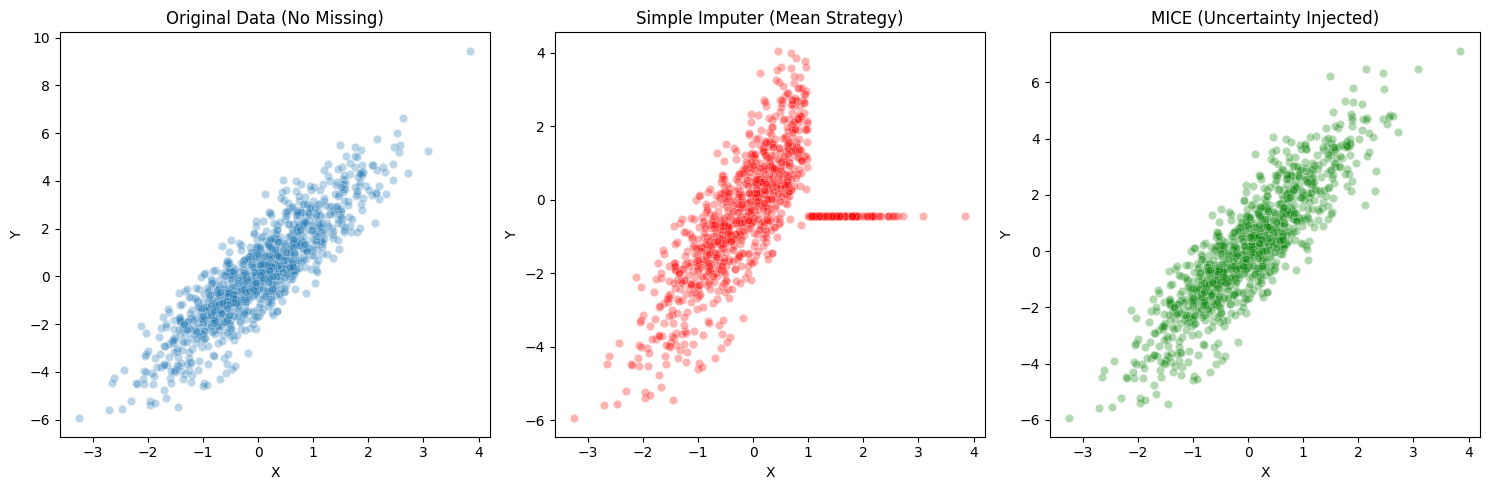

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 1. 데이터 생성 (상관관계가 있는 데이터)
np.random.seed(42)
n_samples = 1000
x = np.random.normal(size=n_samples)
y = 2 * x + np.random.normal(size=n_samples) # x와 상관관계가 있는 y
df = pd.DataFrame({'X': x, 'Y': y})

# 2. 인위적 결측치 발생 (MAR 가정: X값에 따라 Y가 누락될 확률 부여)
df_missing = df.copy()
df_missing.loc[df['X'] > 1, 'Y'] = np.nan # X > 1인 데이터의 Y를 결측치로 만듦 [cite: 48]

# 3. 결측치 처리
# (A) Simple Imputer: 평균값으로 대체 (분산 축소 위험) [cite: 76, 363]
simple_imp = SimpleImputer(strategy='mean')
df_simple = pd.DataFrame(simple_imp.fit_transform(df_missing), columns=['X', 'Y'])

# (B) Iterative Imputer (MICE): 베이지안 회귀를 통한 불확실성 반영 대체 [cite: 369, 416]
mice_imp = IterativeImputer(sample_posterior=True, random_state=42)
df_mice = pd.DataFrame(mice_imp.fit_transform(df_missing), columns=['X', 'Y'])

# 4. 결과 시각화 비교
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='X', y='Y', alpha=0.3)
plt.title("Original Data (No Missing)")

plt.subplot(1, 3, 2)
sns.scatterplot(data=df_simple, x='X', y='Y', alpha=0.3, color='red')
plt.title("Simple Imputer (Mean Strategy)")
# 평균으로 채우면 특정 라인에 데이터가 몰려 분산이 왜곡됨을 확인 [cite: 66]

plt.subplot(1, 3, 3)
sns.scatterplot(data=df_mice, x='X', y='Y', alpha=0.3, color='green')
plt.title("MICE (Uncertainty Injected)")
# 무작위성이 주입되어 원래 데이터의 분포와 유사하게 복구됨 [cite: 292]

plt.tight_layout()
plt.show()